In [20]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch import optim

# necessary for 3d plot even if not used
from mpl_toolkits.mplot3d import Axes3D  # noqa
from matplotlib.collections import PolyCollection
from scipy.stats.mstats import gmean
import os

In [2]:
!pip install pot
import ot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.6 MB/s eta 0:00:00


# 1. Domain Adaptation with OT

## 1.1. Model on source data

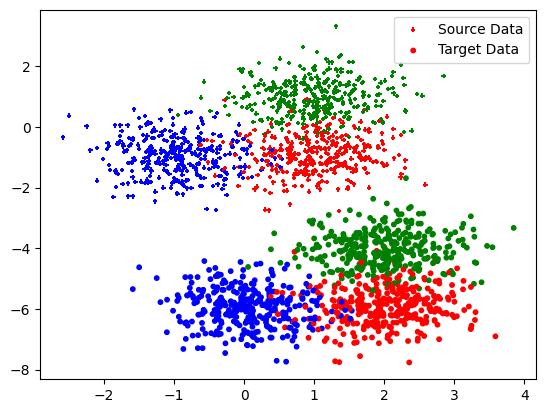

In [3]:
from sklearn import  datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

random_state = 42
# Load the data
centers = [[1, 1], [-1, -1], [1, -1]]
c = 2
Xs, ys = datasets.make_blobs(n_samples=1000, n_features = c, centers= centers, cluster_std=0.6,  random_state=random_state)

Xt = Xs.copy()
yt = ys.copy()
Xt[:, 0] =  Xt[:, 0]+1
Xt[:, 1] =  Xt[:, 1]-5

n_source_samples = 1000
n_target_samples = 1000


colors = np.array(['green', 'blue', 'red'])
plt.scatter(Xs[:, 0], Xs[:, 1], s=10, color=colors[ys], marker = "+", label="Source Data")
plt.scatter(Xt[:, 0], Xt[:, 1], s=10, color=colors[yt], label="Target Data")
plt.legend()
plt.show()

ys = ys.reshape(-1,1)
yt = yt.reshape(-1,1)
# divide into training and test set
Xs_train, Xs_test, ys_train, ys_test = train_test_split(Xs, ys, test_size=0.3, random_state=random_state)
Xt_train, Xt_test, yt_train, yt_test = train_test_split(Xt, yt, test_size=0.3, random_state=random_state)

In [4]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
Ys_train = encoder.fit_transform(ys_train)
Yt_train = encoder.fit_transform(yt_train)
Xt_train = torch.tensor(Xt_train, dtype=torch.float32)
Xs_train = torch.tensor(Xs_train, dtype=torch.float32)
Yt_train = torch.tensor(Yt_train, dtype=torch.float32)
Ys_train = torch.tensor(Ys_train, dtype=torch.float32)

Xt_test = torch.tensor(Xt_test, dtype=torch.float32)
Xs_test = torch.tensor(Xs_test, dtype=torch.float32)
Yt_test = torch.tensor(yt_test, dtype=torch.float32)
Ys_test = torch.tensor(ys_test, dtype=torch.float32)

In [5]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        #self.flatten = nn.Flatten()
        self.g = nn.Sequential(
             nn.Linear(2,16),
             nn.Linear(16,16)) # Feature extractor
        self.f = nn.Linear(16,3) # Classifier

    def forward(self, x):
        x = self.g(x)
        logits = self.f(x)
        return logits

    def predict(self,x):
        return self.forward(x)

In [6]:
def training(X, y, model, optimizer, n_epoch, batch_size=32):
    loss_fn = nn.CrossEntropyLoss()
    for epoch in range(n_epoch):
        for i in range(0, len(X), batch_size):
            Xbatch = X[i:i+batch_size]
            ybatch = y[i:i+batch_size]
            y_pred = model(Xbatch)
            loss = loss_fn(y_pred, ybatch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return model


In [7]:
# Train the model on the source training data
# Convert one-hot labels back to class indices for training/testing
ys_train_idx = torch.argmax(Ys_train, dim=1)
yt_train_idx = torch.argmax(Yt_train, dim=1)

# Initialize model and optimizer
model = NeuralNetwork()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ---- TRAIN SOURCE ----
model = training(Xs_train, ys_train_idx, model, optimizer, n_epoch=50, batch_size=32)


In [8]:
def predict(model, X):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        preds = torch.argmax(logits, dim=1)
    return preds


def accuracy(model, X, y_true):
    preds = predict(model, X)
    y_true = y_true.reshape(-1)
    return (preds == y_true).float().mean().item()


In [9]:
# Test the model on the test source and target data, give the accuracy
# ---- ACCURACY SOURCE ----
ys_test_idx = ys_test.reshape(-1)
acc_source = accuracy(model, Xs_test, ys_test_idx)
print("Source Test Accuracy:", acc_source)

# ---- ACCURACY TARGET ----
yt_test_idx = yt_test.reshape(-1)
acc_target = accuracy(model, Xt_test, yt_test_idx)
print("Target Test Accuracy:", acc_target)

Source Test Accuracy: 0.9399999976158142
Target Test Accuracy: 0.5299999713897705


The model perfomed really well on the Source domain, because that is what it was trained to do. When tested on the target domain, the result is much worse, because the model is not suited to generalize on this new domain.

On the plot below we can see more clearly why it performs badly: it does not account for the domain shift, no green class is predicted because this class is too far from the target domain.

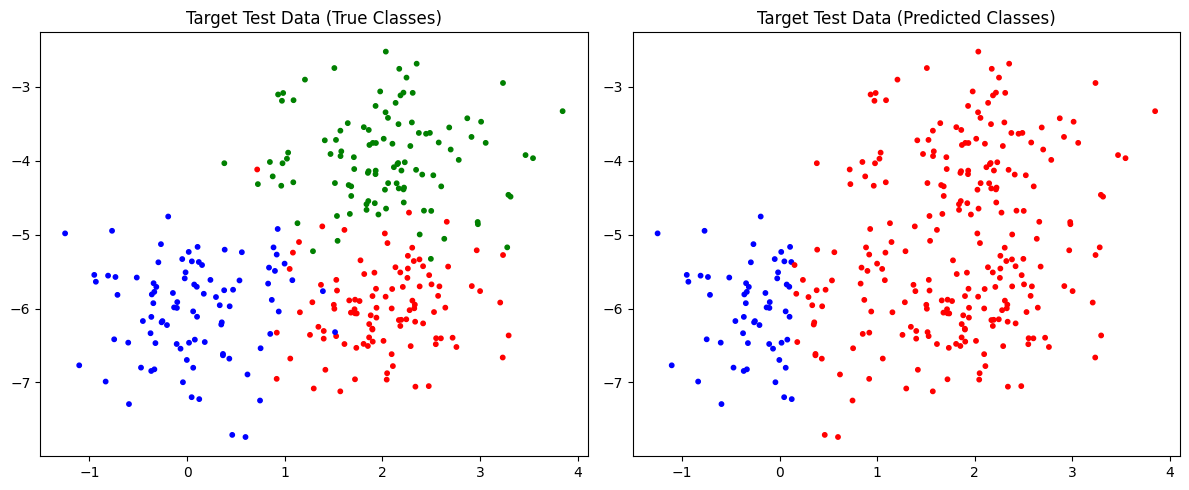

In [10]:
ys_test_pred = predict(model, Xs_test)
yt_test_pred = predict(model, Xt_test)

colors = np.array(['green', 'blue', 'red'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(Xt_test[:, 0], Xt_test[:, 1],
                s=10, color=colors[yt_test_idx], marker="o")
axes[0].set_title("Target Test Data (True Classes)")

axes[1].scatter(Xt_test[:, 0], Xt_test[:, 1],
                s=10, color=colors[yt_test_pred.numpy()], marker="o")
axes[1].set_title("Target Test Data (Predicted Classes)")

plt.tight_layout()
plt.show()

## 1.2 JDOT

In [26]:
# def jdot(Xs,Ys,Xt, model, numIter=20, reg=1):
#     alpha = 1
#     lambd = 0.18

#     # Convert to numpy
#     Xs_np = Xs.detach().cpu().numpy()
#     Xt_np = Xt.detach().cpu().numpy()
#     Ys_np = Ys.detach().cpu().numpy()
#     # print(Xs.shape)

#     n_s = Xs_np.shape[0]
#     n_t = Xt_np.shape[0]
#     a = np.ones(n_s) / n_s
#     b = np.ones(n_t) / n_t

#     Xs_col = Xs_np[:, None, :]
#     Xt_lin = Xt_np[None, :, :]
#     C1 = np.sum((Xs_col - Xt_lin) ** 2, axis=2)
#     # print(C1.shape)

#     optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
#     loss_fn = nn.CrossEntropyLoss()

#     for k in range(numIter):
#         model.eval()
#         with torch.no_grad():
#             logits_t = model(Xt)
#             ypred_t = torch.softmax(logits_t, dim=1).cpu().numpy()

#         C0 = np.sum((Ys_np[:, None, :] - ypred_t[None, :, :]) ** 2, axis=2)
#         # print(C0.shape)
#         # print(C0)
#         C = alpha * C0 + lambd * C1

#         Pi = ot.emd(a, b, C)

#         Yst_np = n_t * Pi.T.dot(Ys_np)
#         Yst = torch.tensor(Yst_np, dtype=torch.float32)

#         y_st_idx = torch.argmax(Yst, dim=1)

#         model.train()
#         for epoch in range(3):
#             optimizer.zero_grad()
#             logits = model(Xt)
#             loss = loss_fn(logits, y_st_idx)
#             loss.backward()
#             optimizer.step()

#         print(f"[Iter {k}] loss = {loss.item():.4f}")

#     return model


In [13]:
def jdot(Xs,Ys,Xt, model, numIter=20, reg=1):
    alpha = 1
    lambd = 0.18
    ns = Xs.shape[0]
    nt = Xt.shape[0]

    a = np.ones(ns) / ns
    b = np.ones(nt) / nt

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    softmax = nn.Softmax(dim=1)

    C1 = torch.cdist(Xs, Xt, p=2.0)**2
    C1 = C1 / torch.median(C1).detach()

    with torch.no_grad():
        logits_t = model(Xt)
        Yt_pred = softmax(logits_t)

    C0 = torch.cdist(Ys.float(), Yt_pred.float(), p=2.0)**2
    # print(C0.shape)
    # print(C0)
    C = alpha*C0 + lambd*C1

    for k in range(numIter):

        Pi = ot.emd(a, b, C.detach().cpu().numpy())

        Pi_t = torch.tensor(Pi, dtype=torch.float32)
        Y_st = nt * Pi_t.T.matmul(Ys)

        for epoch in range(5):
            logits = model(Xt)
            loss = torch.mean(torch.sum(-Y_st * softmax(logits).log(), dim=1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


        with torch.no_grad():
            logits_t = model(Xt)
            Yt_pred = softmax(logits_t)

        C0 = torch.cdist(Ys.float(), Yt_pred.float(), p=2.0)**2
        C = alpha*C0 + lambd*C1

        print(f"Iter {k} | Loss = {loss.item():.4f}")

    return model

In [14]:
model_jdot = NeuralNetwork()
model_jdot = jdot(Xs_train, Ys_train, Xt_train, model_jdot, numIter=20)


Iter 0 | Loss = 0.9690
Iter 1 | Loss = 0.9049
Iter 2 | Loss = 0.8640
Iter 3 | Loss = 0.8234
Iter 4 | Loss = 0.7850
Iter 5 | Loss = 0.7489
Iter 6 | Loss = 0.7146
Iter 7 | Loss = 0.6820
Iter 8 | Loss = 0.6514
Iter 9 | Loss = 0.6222
Iter 10 | Loss = 0.5944
Iter 11 | Loss = 0.5683
Iter 12 | Loss = 0.5436
Iter 13 | Loss = 0.5204
Iter 14 | Loss = 0.4983
Iter 15 | Loss = 0.4775
Iter 16 | Loss = 0.4578
Iter 17 | Loss = 0.4391
Iter 18 | Loss = 0.4215
Iter 19 | Loss = 0.4049


In [15]:
# Test model on the source and target test data
acc_jdot = accuracy(model_jdot, Xt_test, yt_test_idx)
print("JDOT Target Test Accuracy:", acc_jdot)
print("Original acc_target:", acc_target)

# Conclusion on the results

JDOT Target Test Accuracy: 0.8333333134651184
Original acc_target: 0.5299999713897705


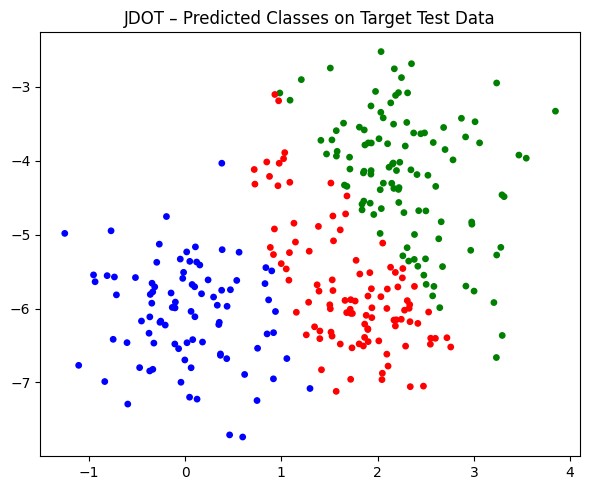

In [16]:
yt_test_pred_jdot = predict(model_jdot, Xt_test).numpy()

colors = np.array(['green', 'blue', 'red'])

plt.figure(figsize=(6, 5))
plt.scatter(Xt_test[:, 0], Xt_test[:, 1],
            s=15, color=colors[yt_test_pred_jdot], marker="o")
plt.title("JDOT – Predicted Classes on Target Test Data")
plt.tight_layout()
plt.show()

Now, Jdot starts to consider some of the domain shift, that helped better predict the blue and green class, greatly increasing the accuaracy.

### What information does the transport plan provides?
Pi describes how much mass from each source sample should be matched to each target sample, that is, a high Pi(i,j) means that source point i is strongly associated with target point j both in feature and label proximity.


### What is the objective of the variable Y_st?
Y_st is a matrix for the labels of the target, that not always exist in the dataset. It encodes the weighted contribution of multiple source points to each target point


### What is the main disavantage of JDOT in a deep learning context?
It requires solving Optimal Transport at every iteration, that brings a high computational cost.

## 1.3 DeepJDOT

In [17]:
def deepJDOT(Xs, Ys, Xt, model, optimizer, n_epoch, batch_size=32, alpha=1.0, lambd=0.18):
    device = next(model.parameters()).device
    n_s = Xs.shape[0]
    n_t = Xt.shape[0]

    ys_idx_all = torch.argmax(Ys, dim=1).to(device)

    loss_ce = nn.CrossEntropyLoss()
    rng = np.random.default_rng(0)

    for epoch in range(n_epoch):
        model.train()

        perm_s = torch.randperm(n_s, device=device)
        for start in range(0, n_s, batch_size):
            end = min(start + batch_size, n_s)
            bs = end - start

            idx_s = perm_s[start:end]
            Xs_b = Xs[idx_s].to(device)
            Ys_b = Ys[idx_s].to(device)
            ys_b_idx = ys_idx_all[idx_s].to(device)


            if n_t >= bs:
                idx_t = torch.from_numpy(rng.choice(n_t, bs, replace=False)).long().to(device)
            else:
                idx_t = torch.from_numpy(rng.choice(n_t, bs, replace=True)).long().to(device)
            Xt_b = Xt[idx_t].to(device)

            z_s = model.g(Xs_b)
            z_t = model.g(Xt_b)

            logits_s = model.f(z_s)
            logits_t = model.f(z_t)

            probs_t = torch.softmax(logits_t, dim=1)

            C0_torch = torch.cdist(Ys_b, probs_t, p=2.0) ** 2
            C1_torch = torch.cdist(z_s, z_t, p=2.0) ** 2

            C_np = (alpha * C0_torch.detach().cpu().numpy()) + (lambd * C1_torch.detach().cpu().numpy())
            a = np.ones((bs,)) / bs
            b = np.ones((bs,)) / bs

            Pi_np = ot.emd(a, b, C_np)
            Pi = torch.tensor(Pi_np, dtype=torch.float32, device=device)

            lot_term = alpha * torch.sum(Pi * C0_torch) + lambd * torch.sum(Pi * C1_torch)
            lsrc = loss_ce(logits_s, ys_b_idx)
            loss = lsrc + lot_term


            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if (epoch + 1) % 10 == 0 or epoch == 0:
            with torch.no_grad():
                model.eval()
                lsrc_val = loss_ce(model.f(model.g(Xs_b)), ys_b_idx).item()
                lot_val = lot_term.item()
            print(f"Epoch {epoch+1}/{n_epoch}  Lsrc={lsrc_val:.4f}  Lot={lot_val:.4f}")

    return model


In [21]:
model = NeuralNetwork()
optimizer = optim.Adam(model.parameters(), lr=0.001)
batch_size = 32
n_epochs = 50
model = training(Xs_train, torch.argmax(Ys_train, dim=1), model, optimizer, 10, batch_size=batch_size)
model = deepJDOT(Xs_train, Ys_train, Xt_train, model, optimizer, n_epoch=n_epochs, batch_size=batch_size, alpha=1.0, lambd=0.18)


Epoch 1/50  Lsrc=0.4077  Lot=13.1587
Epoch 10/50  Lsrc=0.6497  Lot=0.5705
Epoch 20/50  Lsrc=0.5758  Lot=0.5178
Epoch 30/50  Lsrc=0.5304  Lot=0.5838
Epoch 40/50  Lsrc=0.6030  Lot=0.8716
Epoch 50/50  Lsrc=0.5599  Lot=0.2610


In [22]:
# Test model on the source and target test data
acc_source_after = accuracy(model, Xs_test, ys_test.reshape(-1))
acc_target_after = accuracy(model, Xt_test, yt_test.reshape(-1))
print("deepJDOT - Source Test Accuracy:", acc_source_after)
print("deepJDOT - Target Test Accuracy:", acc_target_after)


# Conclusion on the results

After deepJDOT - Source Test Accuracy: 0.7133333086967468
After deepJDOT - Target Test Accuracy: 0.7166666388511658


### Show the accuracy of the model obtained on the target and test samples. What is the difference compared to the result in Section 1.2?
JDOT achieved a higher target accuracy than DeepJDOT, but the later continues significantly better than the baseline.


### What is the main disadvantage of DeepJDOT?
DeepJDOT optimizes the transport plan between source and target samples, the feature representation (network g) and the classifier all at the same time. This creates a problem, besause the OT plan depends on features produced by g, but the optimization of g depends on the OT plan.


### Which method is better DeepJDOT or JDOT? Explain why.
For this example, JDOT presented better results, probably because features are low-dimensional and already meaningful so that learning a deep representation adds unnecessary complexity. But for real high-dimensional data, DeepJDOT becomes better, because learning a representation is essential.

# 2. deepJDOT on CNNs

In [31]:
class CNN_Network(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()

        # -----------------------
        # Feature Extractor g(x)
        # -----------------------
        self.g = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=8, kernel_size=2),
            nn.ReLU(),                     # Output: (batch, 8, 1)
            nn.Flatten(),                  # Output: (batch, 8)
            nn.Linear(8, 16),              # Higher-level features
            nn.ReLU()
        )

        # -----------------------
        # Classifier f(g(x))
        # -----------------------
        self.f = nn.Linear(16, n_classes)

    def forward(self, x):
        # x is (batch, 2) → reshape into CNN format
        x = x.unsqueeze(1)           # (batch, 1, 2)
        z = self.g(x)                # features
        logits = self.f(z)           # class logits
        return logits

    def extract_features(self, x):
        return self.g(x.unsqueeze(1))

In [36]:
def deepJDOT(Xs, Ys, Xt, model, optimizer, n_epoch, batch_size=32, alpha=1.0, lambd=0.18):
    device = next(model.parameters()).device
    n_s = Xs.shape[0]
    n_t = Xt.shape[0]

    ys_idx_all = torch.argmax(Ys, dim=1).to(device)

    loss_ce = nn.CrossEntropyLoss()
    rng = np.random.default_rng(0)

    for epoch in range(n_epoch):
        model.train()

        perm_s = torch.randperm(n_s, device=device)
        for start in range(0, n_s, batch_size):
            end = min(start + batch_size, n_s)
            bs = end - start

            idx_s = perm_s[start:end]
            Xs_b = Xs[idx_s].to(device)
            Ys_b = Ys[idx_s].to(device)
            ys_b_idx = ys_idx_all[idx_s].to(device)

            if n_t >= bs:
                idx_t = torch.from_numpy(rng.choice(n_t, bs, replace=False)).long().to(device)
            else:
                idx_t = torch.from_numpy(rng.choice(n_t, bs, replace=True)).long().to(device)
            Xt_b = Xt[idx_t].to(device)

            z_s = model.g(Xs_b.unsqueeze(1))
            z_t = model.g(Xt_b.unsqueeze(1))

            logits_s = model.f(z_s)
            logits_t = model.f(z_t)

            probs_t = torch.softmax(logits_t, dim=1)

            C0_torch = torch.cdist(Ys_b, probs_t, p=2.0)**2
            C1_torch = torch.cdist(z_s, z_t, p=2.0)**2

            C_np = (alpha * C0_torch.detach().cpu().numpy()) + (lambd * C1_torch.detach().cpu().numpy())
            a = np.ones((bs,)) / bs
            b = np.ones((bs,)) / bs

            Pi_np = ot.emd(a, b, C_np)
            Pi = torch.tensor(Pi_np, dtype=torch.float32, device=device)

            lot_term = alpha * torch.sum(Pi * C0_torch) + lambd * torch.sum(Pi * C1_torch)
            lsrc = loss_ce(logits_s, ys_b_idx)
            loss = lsrc + lot_term

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if (epoch + 1) % 10 == 0 or epoch == 0:
            with torch.no_grad():
                model.eval()
                lsrc_val = loss_ce(model.f(model.g(Xs_b.unsqueeze(1))), ys_b_idx).item()
                lot_val = lot_term.item()
            print(f"Epoch {epoch+1}/{n_epoch}  Lsrc={lsrc_val:.4f}  Lot={lot_val:.4f}")

    return model


In [37]:
model = CNN_Network()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model_deepjdot = deepJDOT(Xs_train, Ys_train, Xt_train,
                          model, optimizer,
                          n_epoch=50, batch_size=32)



Epoch 1/50  Lsrc=1.0947  Lot=1.1211
Epoch 10/50  Lsrc=0.8272  Lot=0.5305
Epoch 20/50  Lsrc=0.4532  Lot=0.4958
Epoch 30/50  Lsrc=0.1529  Lot=0.7903
Epoch 40/50  Lsrc=0.2817  Lot=0.4263
Epoch 50/50  Lsrc=0.2839  Lot=0.3311


In [39]:
yt_test_idx = yt_test.reshape(-1)

acc_source_cnn = accuracy(model_deepjdot, Xs_test, ys_test_idx)
acc_target_cnn = accuracy(model_deepjdot, Xt_test, yt_test_idx)

print("deepJDOT (CNN) - Source Test Accuracy:", acc_source_cnn)
print("deepJDOT (CNN) - Target Test Accuracy:", acc_target_cnn)


deepJDOT (CNN) - Source Test Accuracy: 0.9266666769981384
deepJDOT (CNN) - Target Test Accuracy: 0.38333332538604736


the target-domain accuracy decreased a lot, which is far worse than the previous deepJDOT result and also the baseline. This drop might indicate overfitting to the source domain. the CNN learns features too specialized for the source data, making alignment between source and target distributions more difficult.